In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
data = pd.read_csv("Position_Salaries.csv")
data


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [13]:
data.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [16]:
x = data['Level'].values
y = data['Salary'].values



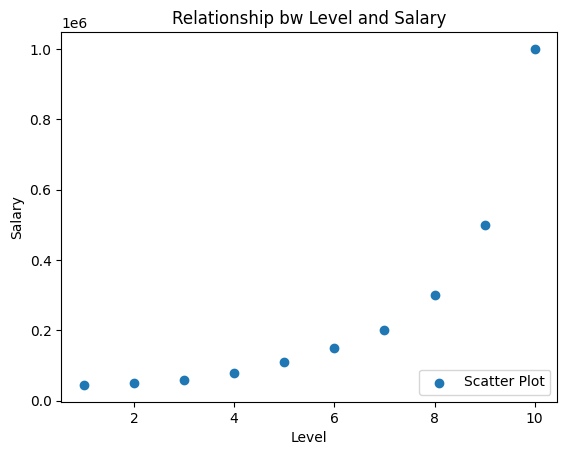

In [17]:
plt.scatter(x,y, label='Scatter Plot')
plt.title("Relationship bw Level and Salary")
plt.xlabel('Level')
plt.ylabel('Salary')
plt.legend(loc=4)
plt.show()


In [19]:
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)
#Reshaping x and y
print(x.shape)
print(y.shape) #New dimensions

(10, 1)
(10, 1)


In [28]:
#Split x and y into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [29]:
#Dimensions of x_train, x_test, y_train, y_test
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(8, 1)
(8, 1)
(2, 1)
(2, 1)


In [30]:
#Fit the linear model
from sklearn.linear_model import LinearRegression
lm = LinearRegression() #Instantiate the linear regression object

lm.fit(x_train, y_train) #Train the model using training datasets

y_pred = lm.predict(x_test) #Make predictions using testing set


In [31]:
a = lm.coef_
b = lm.intercept_
print("Estimated model slope: ",a)
print("Estimated model intercept: ",b)
#

Estimated model slope:  [[87887.93103448]]
Estimated model intercept:  [-240258.62068966]


In [32]:
#Calculate RMSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE value: {:.4f}".format(rmse))

RMSE value: 88544.0987


In [33]:
#Calculate R2 score
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 score value: {:.4f}".format(r2))

R2 score value: 0.8451


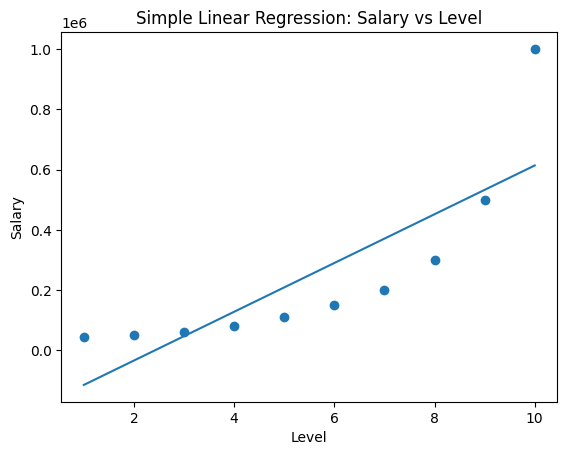

In [26]:
plt.scatter(x, y)
plt.plot(x, y_pred)
plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Simple Linear Regression: Salary vs Level")
plt.show()


In [34]:
print("Training set score: {:.4f}".format(lm.score(x_train, y_train)))
print("Test set score: {:.4f}".format(lm.score(x_test, y_test)))

Training set score: 0.6366
Test set score: 0.8451
